In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import xgboost as xgb
import lightgbm as lgb


# 🔥 Cargar los datos
train = pd.read_csv('/content/drive/MyDrive/AlfredTest/train.csv')
test = pd.read_csv('/content/sample_data/test.csv')
sample_submission = pd.read_csv('/content/sample_data/sample_submission.csv')



In [4]:
#Show the head
print(train.head())
print(test.head())

      Ticker        Date      Open      High       Low     Close    Volume  \
0   ticker_1  1962-01-02  0.000000  0.265828  0.261788  0.261788   25600.0   
1  ticker_20  1962-01-02  0.000000  0.417455  0.412380  0.414917   84139.0   
2  ticker_19  1962-01-02  0.000000  0.101537  0.100789  0.100789  902400.0   
3  ticker_18  1962-01-02  0.000000  0.903030  0.881959  0.881959   51552.0   
4  ticker_17  1962-01-02  0.130512  0.131783  0.129241  0.130512  163200.0   

   Dividends  Stock Splits  
0        0.0           0.0  
1        0.0           0.0  
2        0.0           0.0  
3        0.0           0.0  
4        0.0           0.0  
            ID        Date
0     ticker_1  2024-11-04
1    ticker_10  2024-11-04
2   ticker_100  2024-11-04
3  ticker_1000  2024-11-04
4  ticker_1001  2024-11-04


In [4]:
# ✨ Convertir fecha a tipo datetime
train['Date'] = pd.to_datetime(train['Date'])
test['Date'] = pd.to_datetime(test['Date'])

# ✨ Ordenar por ticker y fecha
train = train.sort_values(['Ticker', 'Date']).reset_index(drop=True)

In [5]:
# ✨ Crear el Target
# Para cada acción, el target es si el precio Close sube o baja después de 30 días
train['Target'] = train.groupby('Ticker')['Close'].shift(-30) > train['Close']
train['Target'] = train['Target'].astype(int)

# ⚠️ Eliminamos filas donde no podemos calcular el target (últimos 30 días de cada acción)
train = train.dropna(subset=['Target'])

In [6]:
# ✨ Función para crear nuevas features
def create_features(df):
    feature_cols = [col for col in df.columns if 'feature' in col]

    # Crear features agregadas basadas en los features disponibles
    df['feature_mean'] = df[feature_cols].mean(axis=1)
    df['feature_std'] = df[feature_cols].std(axis=1)
    df['feature_min'] = df[feature_cols].min(axis=1)
    df['feature_max'] = df[feature_cols].max(axis=1)
    df['feature_median'] = df[feature_cols].median(axis=1)
    df['feature_sum'] = df[feature_cols].sum(axis=1)

    return df



=== Random Forest ===
Best Params: {'max_depth': 9, 'min_samples_split': 5, 'n_estimators': 448}
Validation Accuracy: 0.9000
CV Accuracy: 0.8912 (±0.0246)
Training Time: 32.67s
              precision    recall  f1-score   support

           0       0.86      0.94      0.90        93
           1       0.94      0.87      0.90       107

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200


=== LightGBM ===


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

Best Params: {'learning_rate': np.float64(0.06454749016213018), 'n_estimators': 376, 'num_leaves': 52}
Validation Accuracy: 0.8950
CV Accuracy: 0.8962 (±0.0233)
Training Time: 10.08s
              precision    recall  f1-score   support

           0       0.85      0.95      0.89        93
           1       0.95      0.85      0.90       107

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.89       200
weighted avg       0.90      0.90      0.90       200


=== XGBoost ===


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [20:02:44] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [20:02:45] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [20:02:45] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [20:02:45] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [20:02:45] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

Best Params: {'learning_rate': np.float64(0.012119891565915222), 'max_depth': 3, 'n_estimators': 148}
Validation Accuracy: 0.9050
CV Accuracy: 0.9025 (±0.0318)
Training Time: 16.37s
              precision    recall  f1-score   support

           0       0.86      0.96      0.90        93
           1       0.96      0.86      0.91       107

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.90       200
weighted avg       0.91      0.91      0.91       200



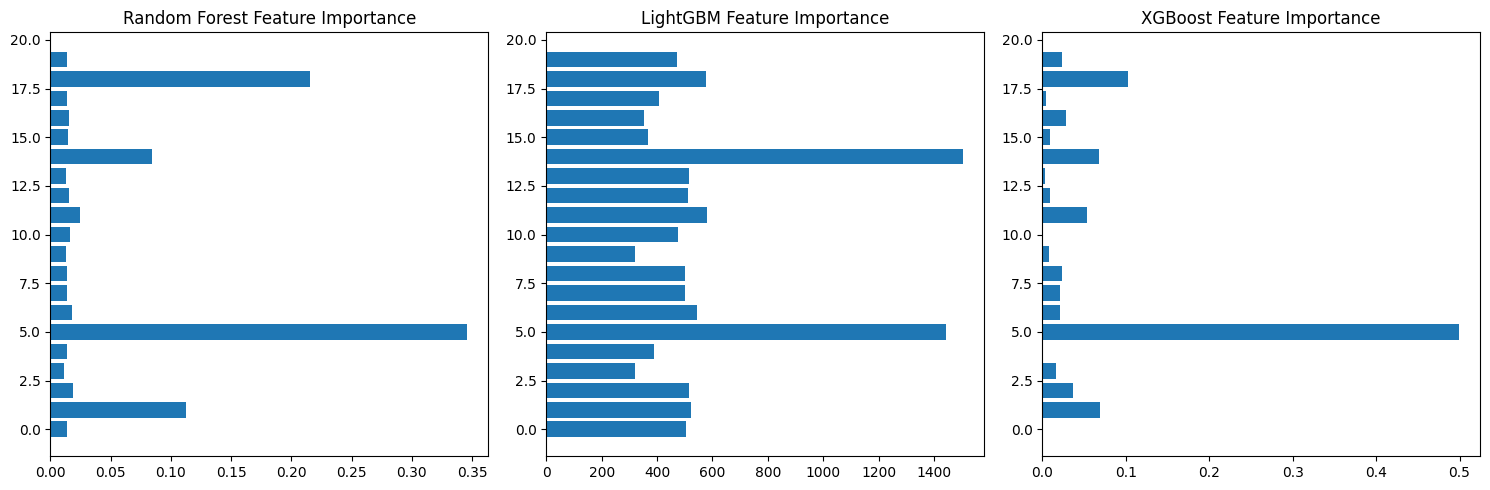


=== Model Comparison Summary ===
Random Forest:
  Validation Accuracy: 0.9000
  CV Accuracy: 0.8912 (±0.0246)
  Training Time: 32.67s
LightGBM:
  Validation Accuracy: 0.8950
  CV Accuracy: 0.8962 (±0.0233)
  Training Time: 10.08s
XGBoost:
  Validation Accuracy: 0.9050
  CV Accuracy: 0.9025 (±0.0318)
  Training Time: 16.37s


In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import lightgbm as lgb
import xgboost as xgb
from scipy.stats import randint, uniform

# Load your dataset (replace with your data)
# df = pd.read_csv('your_data.csv')
# X = df.drop('target', axis=1)
# y = df['target']

# Example with synthetic data (if no dataset is loaded)
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

# Split data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "LightGBM": lgb.LGBMClassifier(random_state=42, verbose=-1),
    "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
}

# Hyperparameter grids for tuning
param_grids = {
    "Random Forest": {
        'n_estimators': randint(100, 500),
        'max_depth': randint(3, 10),
        'min_samples_split': randint(2, 10)
    },
    "LightGBM": {
        'n_estimators': randint(100, 500),
        'learning_rate': uniform(0.01, 0.3),
        'num_leaves': randint(20, 100)
    },
    "XGBoost": {
        'n_estimators': randint(100, 500),
        'learning_rate': uniform(0.01, 0.3),
        'max_depth': randint(3, 10)
    }
}

# Train, tune, and evaluate models
results = {}
for name, model in models.items():
    print(f"\n=== {name} ===")

    # RandomizedSearchCV for hyperparameter tuning
    search = RandomizedSearchCV(
        model,
        param_grids[name],
        n_iter=10,
        cv=3,
        scoring='accuracy',
        random_state=42
    )

    start_time = time.time()
    search.fit(X_train, y_train)
    train_time = time.time() - start_time

    # Best model
    best_model = search.best_estimator_
    y_pred = best_model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)

    # Cross-validation score
    cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='accuracy')

    # Store results
    results[name] = {
        'model': best_model,
        'accuracy': accuracy,
        'cv_mean_accuracy': np.mean(cv_scores),
        'cv_std_accuracy': np.std(cv_scores),
        'train_time': train_time,
        'best_params': search.best_params_
    }

    # Print results
    print(f"Best Params: {search.best_params_}")
    print(f"Validation Accuracy: {accuracy:.4f}")
    print(f"CV Accuracy: {np.mean(cv_scores):.4f} (±{np.std(cv_scores):.4f})")
    print(f"Training Time: {train_time:.2f}s")
    print(classification_report(y_val, y_pred))

# Compare feature importance
plt.figure(figsize=(15, 5))
for i, (name, res) in enumerate(results.items(), 1):
    plt.subplot(1, 3, i)
    if hasattr(res['model'], 'feature_importances_'):
        importances = res['model'].feature_importances_
        plt.barh(range(len(importances)), importances)
        plt.title(f"{name} Feature Importance")
    else:
        plt.text(0.5, 0.5, "No feature importance", ha='center')
plt.tight_layout()
plt.show()

# Print summary
print("\n=== Model Comparison Summary ===")
for name, res in results.items():
    print(f"{name}:")
    print(f"  Validation Accuracy: {res['accuracy']:.4f}")
    print(f"  CV Accuracy: {res['cv_mean_accuracy']:.4f} (±{res['cv_std_accuracy']:.4f})")
    print(f"  Training Time: {res['train_time']:.2f}s")


In [2]:
test = pd.read_csv('/content/sample_data/test.csv')
print(test)

               ID        Date
0        ticker_1  2024-11-04
1       ticker_10  2024-11-04
2      ticker_100  2024-11-04
3     ticker_1000  2024-11-04
4     ticker_1001  2024-11-04
...           ...         ...
4995   ticker_995  2024-11-04
4996   ticker_996  2024-11-04
4997   ticker_997  2024-11-04
4998   ticker_998  2024-11-04
4999   ticker_999  2024-11-04

[5000 rows x 2 columns]
